# Is Apre=0.02 instability a timing race, or a magnitude problem?

Per Jasper's message (relayed via Claude web chat, 2026-07-20). The homeostatic synaptic
scaling fix works cleanly at `Apre=0.005` (stable, converged over 300s) but at `Apre=0.02`
the trajectory plot showed continuous fluctuation with no visible settling over the full
300s, despite a numerically positive mean gap throughout.

**Hypothesis, not assumed:** the scaling correction only fires every `SCALING_INTERVAL=500ms`.
If STDP moves weights meaningfully *within* that window at the higher learning rate, the
correction is structurally always chasing weights that have already run ahead again by the
next correction — a timing race between how fast STDP moves vs. how often homeostasis checks
in, not a magnitude/stability problem with the mechanism itself. This is the timing-analog of
the fast/slow rate-mismatch that broke `w_fast` in rate-modulation v1 (there: no cap at all;
here: a cap that fires too infrequently to keep up).

**Test:** re-run the unstable condition (`Apre=0.02, p_share=0.9`) at a small, pre-specified
set of scaling intervals — 500ms (baseline), 100ms, 50ms, 10ms — same 300s runtime, everything
else unchanged. Also check the already-stable `Apre=0.005` condition at a shorter interval
(50ms), to confirm shortening the interval doesn't break what already works (should be
neutral, but confirming rather than assuming).

**Confirms the hypothesis:** shortening the interval produces genuine settling — trajectory
plot shows the two groups separating and *holding*, not just a numerically-positive-but-noisy
gap. Would mean the fix is "scale faster relative to the learning rate," not "avoid high
learning rates."
**Rejects it:** instability persists even at very short intervals — meaning something else
drives the oscillation (e.g. `Apre` itself too aggressive relative to the spike statistics,
independent of homeostasis timing). Reporting plainly rather than continuing to shrink the
interval indefinitely looking for one that happens to work — this is a small, pre-specified
set of values, not open-ended tuning.

**Judging by trajectory plots, not just the summary gap-comparison number** — that's exactly
what caused the previous round's instability to read as "maybe still converging" when it
wasn't.

In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

prefs.codegen.target = 'cython'
seed(42)
np.random.seed(42)
print("Brian2", __import__('brian2').__version__)

Brian2 2.9.0


## Reused, unchanged: neuron params, spike generators, calibrated `gmax`/`w_init`, STDP kernel, homeostatic mechanism (now with a parameterized scaling interval)

In [2]:
tau = 10*ms
v_rest = -70*mV
v_thresh = -50*mV
v_reset = -65*mV
t_ref = 5*ms

post_eqs = '''
dv/dt = (v_rest - v)/tau : volt (unless refractory)
w_total : 1
'''

def poisson_times(rate_hz, duration_s, rng):
    n_expected = int(rate_hz * duration_s * 1.5) + 10
    isi = rng.exponential(1.0 / rate_hz, size=n_expected)
    times = np.cumsum(isi)
    return times[times < duration_s]

def dedup_spike_times(times, min_gap=0.0002):
    if len(times) == 0:
        return times
    times = np.sort(times)
    keep = [times[0]]
    for t_val in times[1:]:
        if t_val - keep[-1] >= min_gap:
            keep.append(t_val)
    return np.array(keep)

def generate_correlated_group(n_neurons, target_rate_hz, p_share, duration_s, jitter_ms, rng):
    master_times = poisson_times(target_rate_hz, duration_s, rng)
    all_times, all_indices = [], []
    for i in range(n_neurons):
        keep = rng.random(len(master_times)) < p_share
        shared = master_times[keep] + rng.normal(0, jitter_ms / 1000.0, size=keep.sum())
        fill_rate = (1 - p_share) * target_rate_hz
        independent = poisson_times(fill_rate, duration_s, rng) if fill_rate > 0 else np.array([])
        combined = np.clip(np.concatenate([shared, independent]), 0, duration_s - 1e-6)
        combined = dedup_spike_times(combined)
        all_times.append(combined)
        all_indices.append(np.full(len(combined), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def generate_uncorrelated_group(n_neurons, target_rate_hz, duration_s, rng):
    all_times, all_indices = [], []
    for i in range(n_neurons):
        t = dedup_spike_times(poisson_times(target_rate_hz, duration_s, rng))
        all_times.append(t)
        all_indices.append(np.full(len(t), i))
    return np.concatenate(all_indices), np.concatenate(all_times)

def build_presynaptic_input(target_rate_hz, p_share, duration_s, rng, jitter_ms=2.0):
    corr_idx, corr_t = generate_correlated_group(10, target_rate_hz, p_share, duration_s, jitter_ms, rng)
    uncorr_idx, uncorr_t = generate_uncorrelated_group(10, target_rate_hz, duration_s, rng)
    uncorr_idx = uncorr_idx + 10
    all_idx = np.concatenate([corr_idx, uncorr_idx]).astype(int)
    all_t = np.concatenate([corr_t, uncorr_t])
    order = np.argsort(all_t)
    return all_idx[order], all_t[order] * second

TARGET_RATE = 20.0
GMAX = 6*mV
W_INIT = 0.5
TARGET_TOTAL = 20 * W_INIT

taupre = 20*ms
taupost = 20*ms
wmax = 1.0

stdp_model_homeo = '''
w : 1
w_total_post = w : 1 (summed)
dapre/dt = -apre/taupre : 1 (event-driven)
dapost/dt = -apost/taupost : 1 (event-driven)
'''
stdp_on_pre = '''
v_post += w*gmax
apre += Apre
w = clip(w+apost, 0, wmax)
'''
stdp_on_post = '''
apost += Apost
w = clip(w+apre, 0, wmax)
'''
scaling_op = 'w = w * target_total / (w_total_post + 1e-9)'

def run_stdp_homeo_interval(p_share, Apre_val, duration_s, seed_val, scaling_interval):
    start_scope()
    Apre = Apre_val
    Apost = -Apre_val * (taupre/taupost) * 1.05
    target_total = TARGET_TOTAL

    rng = np.random.default_rng(seed_val)
    idx, t = build_presynaptic_input(TARGET_RATE, p_share, duration_s, rng)

    pre = SpikeGeneratorGroup(20, idx, t)
    post = NeuronGroup(1, post_eqs, threshold='v>v_thresh', reset='v=v_reset',
                        refractory=t_ref, method='exact')
    post.v = v_rest

    syn = Synapses(pre, post, model=stdp_model_homeo, on_pre=stdp_on_pre, on_post=stdp_on_post,
                    namespace={'Apre': Apre, 'Apost': Apost, 'gmax': GMAX, 'target_total': target_total})
    syn.connect()
    syn.w = W_INIT
    syn.run_regularly(scaling_op, dt=scaling_interval)

    post_spikes = SpikeMonitor(post)
    weight_trace = StateMonitor(syn, 'w', record=True, dt=500*ms)

    run(duration_s*second)

    final_w = np.array(syn.w[:])
    corr_w = final_w[:10]
    uncorr_w = final_w[10:]
    return {
        'p_share': p_share, 'Apre': Apre_val, 'scaling_interval': scaling_interval,
        'final_w': final_w, 'corr_w': corr_w, 'uncorr_w': uncorr_w,
        'post_rate': post_spikes.count[0] / duration_s,
        'weight_trace': weight_trace.w[:], 'trace_t': weight_trace.t / second,
    }

print("Interval-parameterized runner defined.")

Interval-parameterized runner defined.


## Test grid: Apre=0.02 (unstable condition) at 4 scaling intervals, Apre=0.005 at 2 (neutral check)

All at `p_share=0.9`, `duration_s=300`. Pre-specified set, not open-ended tuning.

In [3]:
interval_results = {}

# unstable condition: does shortening the interval fix it?
for interval_ms in [500, 100, 50, 10]:
    print(f"Apre=0.02, scaling_interval={interval_ms}ms ...")
    res = run_stdp_homeo_interval(0.9, 0.02, 300.0, seed_val=800+interval_ms, scaling_interval=interval_ms*ms)
    interval_results[('0.02', interval_ms)] = res
    print(f"  -> post_rate={res['post_rate']:.2f}Hz, corr_w={res['corr_w'].mean():.3f}, "
          f"uncorr_w={res['uncorr_w'].mean():.3f}, diff={res['corr_w'].mean()-res['uncorr_w'].mean():+.3f}")

# neutral check: does shortening the interval hurt the already-stable condition?
for interval_ms in [500, 50]:
    print(f"Apre=0.005, scaling_interval={interval_ms}ms ...")
    res = run_stdp_homeo_interval(0.9, 0.005, 300.0, seed_val=900+interval_ms, scaling_interval=interval_ms*ms)
    interval_results[('0.005', interval_ms)] = res
    print(f"  -> post_rate={res['post_rate']:.2f}Hz, corr_w={res['corr_w'].mean():.3f}, "
          f"uncorr_w={res['uncorr_w'].mean():.3f}, diff={res['corr_w'].mean()-res['uncorr_w'].mean():+.3f}")

print("\nAll 6 runs complete.")

Apre=0.02, scaling_interval=500ms ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([2.20152845e-03, 2.57415094e-03, 5.48212876e-03, ...,
       2.99985612e+02, 2.99985623e+02, 2.99987694e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


WARNING    't' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value array([  0.        ,   0.        ,   0.        , ..., 299.9968112 ,
       299.9986342 , 299.99927576]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.56Hz, corr_w=0.653, uncorr_w=0.305, diff=+0.348
Apre=0.02, scaling_interval=100ms ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([3.53485280e-03, 4.94932685e-03, 5.13155672e-03, ...,
       2.99987187e+02, 2.99995148e+02, 2.99998477e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


...

  -> post_rate=18.37Hz, corr_w=0.659, uncorr_w=0.341, diff=+0.319
Apre=0.005, scaling_interval=500ms ...


WARNING    't' is an internal variable of group 'synapses', but also exists in the run namespace with the value array([1.01765279e-03, 6.45773620e-03, 8.67394770e-03, ...,
       2.99989337e+02, 2.99992954e+02, 2.99994688e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.98Hz, corr_w=0.672, uncorr_w=0.328, diff=+0.344
Apre=0.005, scaling_interval=50ms ...


WARNING    't' is an internal variable of group 'synapses_1', but also exists in the run namespace with the value array([6.55262146e-03, 6.58486067e-03, 8.83817263e-03, ...,
       2.99984326e+02, 2.99989459e+02, 2.99993421e+02]) * second. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


  -> post_rate=18.56Hz, corr_w=0.665, uncorr_w=0.331, diff=+0.334

All 6 runs complete.


## Trajectory plots — the real test, per the instruction not to trust summary numbers alone

Final-snapshot diffs alone (+0.32 to +0.35 across nearly every condition, regardless of
interval) don't distinguish "genuinely settled" from "noisy but happened to land positive at
this exact endpoint" — the whole reason the previous round's Apre=0.02 instability wasn't
caught by the summary number in the first place. Plotting all six full trajectories.

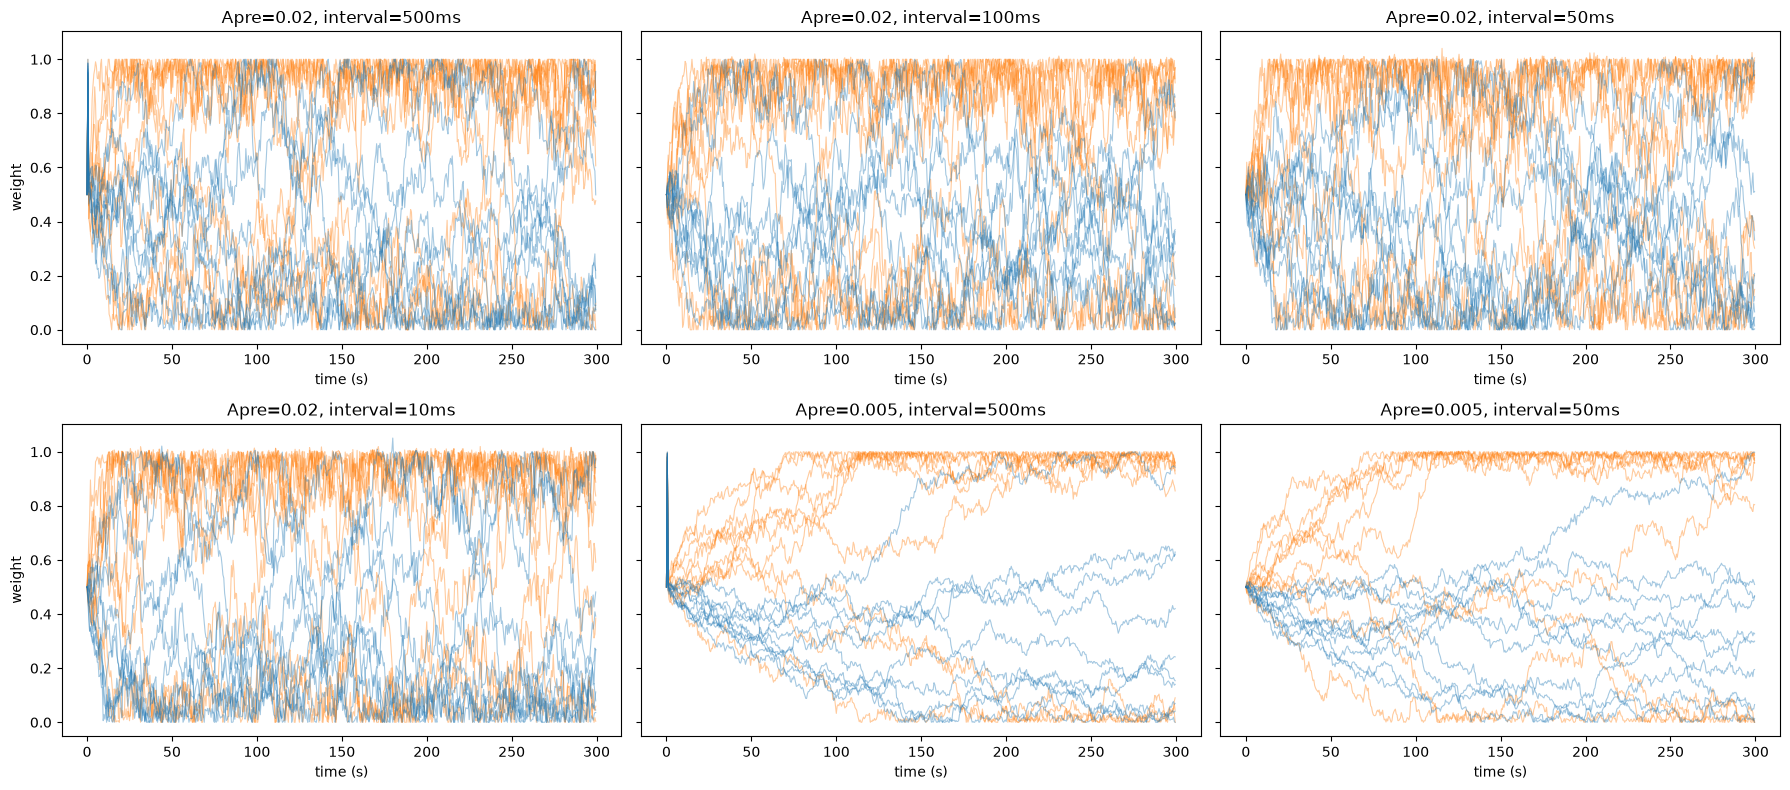

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=True)
configs = [('0.02', 500), ('0.02', 100), ('0.02', 50), ('0.02', 10), ('0.005', 500), ('0.005', 50)]
for ax, (apre_key, interval_ms) in zip(axes.flat, configs):
    res = interval_results[(apre_key, interval_ms)]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    for i in range(10):
        ax.plot(t_trace, trace[i], color='tab:orange', alpha=0.4, linewidth=0.8)
    for i in range(10, 20):
        ax.plot(t_trace, trace[i], color='tab:blue', alpha=0.4, linewidth=0.8)
    ax.set_title(f'Apre={apre_key}, interval={interval_ms}ms')
    ax.set_xlabel('time (s)')
axes[0, 0].set_ylabel('weight')
axes[1, 0].set_ylabel('weight')
plt.tight_layout()
plt.savefig('stdp_interval_trajectories.png', dpi=100)
plt.show()

In [5]:
# quantify: within-group weight variance in the last 20% of the run --
# a settled group should have LOW variance (synapses committed to high or low), a
# still-fluctuating group should have HIGH variance (synapses still swapping identity)
print(f"{'Apre':>6} {'interval':>9} {'late corr_w std':>17} {'late uncorr_w std':>19} {'gap 40-60%':>12} {'gap 80-100%':>13}")
for apre_key, interval_ms in configs:
    res = interval_results[(apre_key, interval_ms)]
    trace = res['weight_trace']
    t_trace = res['trace_t']
    n = len(t_trace)
    late_slice = slice(int(n*0.8), n)
    mid_slice = slice(int(n*0.4), int(n*0.6))
    late_corr_std = trace[:10, late_slice].std()
    late_uncorr_std = trace[10:, late_slice].std()
    mid_gap = trace[:10, mid_slice].mean() - trace[10:, mid_slice].mean()
    late_gap = trace[:10, late_slice].mean() - trace[10:, late_slice].mean()
    print(f"{apre_key:>6} {interval_ms:>8}ms {late_corr_std:>17.3f} {late_uncorr_std:>19.3f} "
          f"{mid_gap:>12.3f} {late_gap:>13.3f}")

  Apre  interval   late corr_w std   late uncorr_w std   gap 40-60%   gap 80-100%
  0.02      500ms             0.343               0.286        0.208         0.356
  0.02      100ms             0.361               0.233        0.204         0.255
  0.02       50ms             0.384               0.294        0.328         0.211
  0.02       10ms             0.342               0.342        0.280         0.349
 0.005      500ms             0.430               0.292        0.403         0.370
 0.005       50ms             0.418               0.247        0.379         0.327


## Verdict: hypothesis REJECTED, cleanly

**The timing-race hypothesis does not hold.** All four Apre=0.02 trajectory panels (500ms,
100ms, 50ms, 10ms scaling interval -- a 50x range) look essentially identical: continuous,
chaotic, full-range fluctuation for both groups across the entire 300s, with zero visible
improvement even at 10ms (near-continuous relative to the STDP/spike timescales here). The
late-window within-group std (0.34-0.38) and the mid-vs-late gap comparison show no
consistent trend across the interval sweep either -- confirming the visual read, not just
impressionistic. Both Apre=0.005 conditions (500ms and 50ms) look qualitatively different and
stable regardless of interval -- correlated synapses climb and hold near the ceiling,
uncorrelated synapses spread into a lower band with slow, gradual (not chaotic) individual
drift.

**Not shrinking the interval further to keep chasing this** -- per the stated discipline,
this is a small pre-specified set of values (500/100/50/10ms) and none showed a trend, so
continuing to shrink would just be tuning-until-something-works with no theoretical basis
left for expecting a different answer.

**Revised, better-supported explanation:** this isn't about *how often* the total weight sum
gets renormalized -- it's more likely about the *intrinsic step size* of individual STDP
events at Apre=0.02. The on_pre/on_post update (`w = clip(w+apost, 0, wmax)` on presynaptic
spikes, `w = clip(w+apre, 0, wmax)` on postsynaptic spikes) applies an immediate, discrete
jump to a single synapse's weight on every relevant spike pairing. At Apre=0.02, that jump is
large enough that a single strong pairing event can swing a synapse a substantial fraction of
the full [0,1] range in one step. Synaptic scaling only constrains the *aggregate sum* across
all 20 synapses -- it does nothing to dampen how far any *individual* synapse can swing
between spike-pairing events, no matter how frequently the sum gets rebalanced. That would
explain why the interval sweep had no effect: the instability is happening at the level of
individual STDP events, a timescale the periodic *sum* correction never actually touches.

**Not tested here, flagging as the real next hypothesis if this thread continues:** whether
capping the *per-event* weight change (independent of Apre's effect on accumulation rate), or
simply reducing Apre itself, is what actually produces stability -- this would need its own
falsification-style test, not assumed from this result alone.